In [19]:
#Setup and Imports
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Dict, Iterable, List, Optional, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [20]:
class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""
        pass

In [21]:
@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost

In [22]:
def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []

    while node is not None:
        path.append(node.state)
        node = node.parent

    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []

    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent

    actions.reverse()
    return actions


def state_is_on_path(node: Node, state: Any) -> bool:
    """
    Return True if state already appears on the path from the root to node.

    This is useful for depth-limited search because DLS often uses path-cycle
    checking instead of a global reached set.
    """
    while node is not None:
        if node.state == state:
            return True
        node = node.parent

    return False


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Limit": result.limit,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier/stack": result.max_frontier_size,
        "Reached states": result.reached_count,
    }


def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])

In [23]:
# Grid Search Problem
MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}


class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        start, goal:
            Tuples in the form (row, col).
        """
        self.grid = grid
        self.start = start
        self.goal = goal

        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start

    def is_goal(self, state: Tuple[int, int]) -> bool:
        # TODO 1:
        # Return True if state is equal to the goal state.
        if state == self.goal:
            return True
        return False
        raise NotImplementedError("Complete GridProblem.is_goal")

    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:
        # TODO 2:
        # Return a list of legal action names.
        #
        # Steps:
        # 1. Create an empty list called legal_actions.
        # 2. For each action in MOVES:
        #       a. Compute the neighbour cell.
        #       b. Check that it is in bounds.
        #       c. Check that it is free.
        #       d. If valid, add the action name to legal_actions.
        # 3. Return legal_actions.

        legal_actions = []
        for action, (dr, dc) in MOVES.items():
            neighbour = (state[0] + dr, state[1] + dc)
            if self.in_bounds(neighbour) and self.is_free(neighbour):
                legal_actions.append(action)
        return legal_actions
        raise NotImplementedError("Complete GridProblem.actions")

    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        # TODO 3:
        # Return the next state after applying action to state.
        #
        # Hint:
        # dr, dc = MOVES[action]
        # return (row + dr, col + dc)

        dr, dc = MOVES[action]
        return (state[0]+ dr, state[1]+dc)
        raise NotImplementedError("Complete GridProblem.result")

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        # TODO 4:
        # In this lab, each valid move has a cost of 1.
        # Return 1.
        return 1.0
        raise NotImplementedError("Complete GridProblem.action_cost")
         

In [24]:
test_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]

test_problem = GridProblem(test_grid, start=(0, 0), goal=(2, 2))

assert test_problem.initial_state() == (0, 0)
assert test_problem.is_goal((2, 2)) is True
assert test_problem.is_goal((0, 0)) is False
assert test_problem.actions((0, 0)) == ["RIGHT"]
assert test_problem.result((0, 0), "RIGHT") == (0, 1)
assert test_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 1

print("GridProblem self-check passed.")  



GridProblem self-check passed.


In [25]:
sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

problem = GridProblem(sample_grid, start, goal)



In [26]:
# Visualisation Helper
def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()

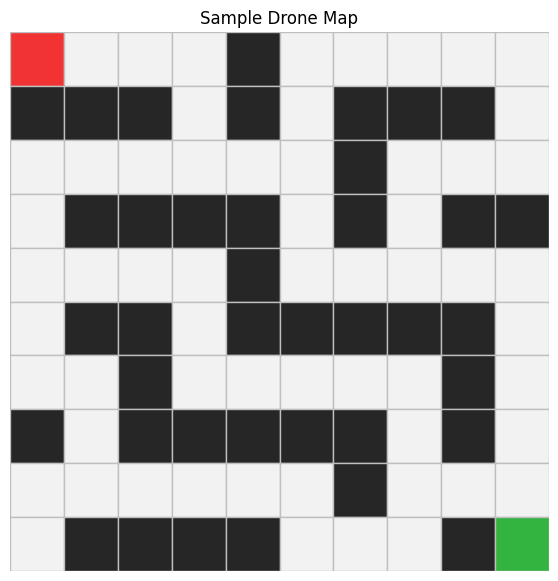

In [27]:
plot_path(sample_grid, start, goal, title="Sample Drone Map")

In [28]:
#Expand method
class SearchAlgorithm(ABC):
    """Base class for search algorithms."""

    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
        # TODO 5:
        # Implement the AIMA-style EXPAND(problem, node).
        #
        # Pseudocode:
        # s <- node.STATE
        # for each action in problem.ACTIONS(s):
        #     s_prime <- problem.RESULT(s, action)
        #     cost <- node.PATH_COST + problem.ACTION_COST(s, action, s_prime)
        #     yield NODE(STATE=s_prime, PARENT=node, ACTION=action, PATH_COST=cost)

        s = node.state
        for action in problem.actions(s):
            s_prime = problem.result(s, action)
            cost = node.path_cost + problem.action_cost(s, action, s_prime)
            yield Node(state=s_prime, parent=node, action=action, path_cost=cost)
        

    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass

In [29]:
# Breadth-First Search(BFS)
class BreadthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "BFS"

        # TODO 6:
        # Implement BFS graph search using a FIFO queue.
        #
        # Steps:
        # 1. Create the initial node from problem.initial_state().
        # 2. If the initial state is the goal, return success.
        # 3. Create a deque frontier and add the initial node.
        # 4. Create a reached set and add the initial state.
        # 5. While frontier is not empty:
        #       a. pop from the LEFT of the deque.
        #       b. increment nodes_expanded.
        #       c. expand the node.
        #       d. for each child:
        #            i. if child is goal, return success.
        #           ii. if child.state is not in reached:
        #                  add child.state to reached.
        #                  append child to frontier.
        #       e. update max_frontier_size.
        # 6. Return failure if no solution is found.
        node = Node(problem.initial_state())
        if problem.is_goal(node.state):  
            return SearchResult(      
                algorithm=algorithm,
                status="Success",
                solution=node,
                nodes_expanded=0,
                max_frontier_size=1,
                reached_count=1
            )
        
        frontier = deque([node])
        reached = {problem.initial_state()}

        nodes_expanded = 0
        max_frontier_size = 1

        while frontier:
            node = frontier.popleft()
            nodes_expanded += 1


            for child in self.expand(problem,node):
                s = child.state
                if problem.is_goal(s):
                    return SearchResult(
                        algorithm=algorithm,
                        status="Success",
                        solution=child,
                        nodes_expanded=nodes_expanded,
                        max_frontier_size=max_frontier_size,
                        reached_count=len(reached) + 1
                        )
                if s not in reached:
                    reached.add(s)
                    frontier.append(child)
                
                max_frontier_size +=1

        return SearchResult(
            algorithm=algorithm,
            status="Failure",
            solution=None,
            nodes_expanded=len(reached),
            max_frontier_size=len(frontier),
        )
    
        # Hint:
        # frontier = deque([node])
        # node = frontier.popleft()
        raise NotImplementedError("Complete BreadthFirstSearch.search")

In [30]:
# Depth-First Search(DFS)
class DepthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "DFS"

        # TODO 7:
        # Implement DFS graph search using a stack.
        #
        # Steps:
        # 1. Create the initial node.
        # 2. If the initial state is the goal, return success.
        # 3. Use a Python list as the stack frontier.
        # 4. Use a reached set.
        # 5. While frontier is not empty:
        #       a. pop from the end of the list.
        #       b. increment nodes_expanded.
        #       c. expand the node.
        #       d. add unreached children to the stack.
        #       e. update max_frontier_size.
        
        node = Node(problem.initial_state())
        if problem.is_goal(node.state):
            return SearchResult(
                algorithm=algorithm,
                status="Success",
                solution=node,
                nodes_expanded=0,
                max_frontier_size=1,
                reached_count=1
            )
        frontier = [node]
        reached = {problem.initial_state()}

        nodes_expanded = 0
        max_frontier_size = 0

        while frontier:
            node = frontier.pop()
            nodes_expanded +=1
            
            for child in self.expand(problem,node):
                s = child.state
                if problem.is_goal(s):
                    return SearchResult(
                        algorithm=algorithm,
                        status="Success",
                        solution=child,
                        nodes_expanded=nodes_expanded,
                        max_frontier_size=max_frontier_size,
                        reached_count=len(reached) + 1
                        )
                if s not in reached:
                    reached.add(s)
                    frontier.append(child)
                
                max_frontier_size +=1

        return SearchResult(
            algorithm=algorithm,
            status="Failure",
            solution=None,
            nodes_expanded=len(reached),
            max_frontier_size=len(frontier)
        )
        # Note:
        # If you want DFS to explore actions in the same order as MOVES,
        # you may need to reverse the children before pushing them.



In [31]:
# Depth-Limited Search (DLS) 
class DepthLimitedSearch(SearchAlgorithm):
    def search(self, problem: Problem, limit: int = 10) -> SearchResult:
        algorithm = "DLS"

        initial_node = Node(problem.initial_state())

        metrics = {
            "nodes_expanded": 0,
            "max_stack_size": 1,
        }

        solution, status = self._recursive_dls(
            problem=problem,
            node=initial_node,
            limit=limit,
            metrics=metrics,
            current_stack_size=1,
        )

        return SearchResult(
            algorithm=algorithm,
            status=status,
            solution=solution,
            nodes_expanded=metrics["nodes_expanded"],
            max_frontier_size=metrics["max_stack_size"],
            reached_count=0,
            limit=limit,
        )

    def _recursive_dls(
        self,
        problem: Problem,
        node: Node,
        limit: int,
        metrics: Dict[str, int],
        current_stack_size: int,
    ) -> Tuple[Optional[Node], str]:
        # TODO 8:
        # Implement recursive depth-limited search.
        #
        # Steps:
        # 1. If node.state is goal, return (node, "success").
        # 2. Else if node.depth >= limit, return (None, "cutoff").
        # 3. Otherwise:
        #       a. increment metrics["nodes_expanded"].
        #       b. set cutoff_occurred = False.
        #       c. for each child in expand(problem, node):
        #             i. skip the child if child.state already appears on the current path.
        #            ii. update max_stack_size.
        #           iii. recursively call _recursive_dls on the child.
        #            iv. if result is "success", return success immediately.
        #             v. if result is "cutoff", set cutoff_occurred = True.
        #       d. after all children:
        #             if cutoff_occurred, return (None, "cutoff")
        #             else return (None, "failure")

        
        if problem.is_goal(node.state):
            return(node,"success")
        elif node.depth >= limit:
            return(None,"Cutoff")
        else:
            metrics["nodes_expanded"] +=1
            cutoff_occurred = False

            for child in self.expand(problem,node):
                if state_is_on_path(node,child):
                    continue

                current_stack_size+=1
                metrics["max_stack_size"] = max(metrics["max_stack_size"],current_stack_size)

                result_node,status=self._recursive_dls(
                    problem,
                    child,
                    limit,
                    metrics,
                    current_stack_size
                )
                if status == "success":
                    return (result_node,"success")
                if status == "cutoff":
                    cutoff_occurred = True
            
            if cutoff_occurred:
                return (None,"Cutoff")
            else:
                return (None,"Failure")
        raise NotImplementedError("Complete DepthLimitedSearch._recursive_dls")


In [32]:
# Iterative Deepening Search (IDS)
class IterativeDeepeningSearch(SearchAlgorithm):
    def search(self, problem: Problem, max_depth: int = 50) -> SearchResult:
        algorithm = "IDS"

        # TODO 9:
        # Implement IDS by repeatedly running DLS from limit 0 to max_depth.
        #
        # Requirements:
        # 1. Keep a list called iteration_log.
        # 2. Accumulate total nodes expanded across all DLS iterations.
        # 3. Track the maximum stack size seen in any DLS run.
        # 4. If a DLS run returns success, return a SearchResult for IDS.
        # 5. If a DLS run returns failure, IDS can stop early and return failure.
        # 6. If all limits return cutoff up to max_depth, return cutoff.
        
        iteration_log = []
        total_nodes_expanded = 0
        max_stack_size =0

        for limit in range(0,max_depth+1):
            dls = DepthLimitedSearch()
            result = dls.search(problem,limit=limit)

            total_nodes_expanded += result.nodes_expanded
            max_stack_size = max(max_stack_size, result.max_frontier_size)

            
            iteration_log.append({
                "limit": limit,
                "status": result.status,
                "nodes_expanded": result.nodes_expanded
            })

            if result.status == "success":
                return SearchResult(
                    algorithm=algorithm,
                    status="Success",
                    solution=result.solution,
                    nodes_expanded=total_nodes_expanded,
                    max_frontier_size=max_stack_size,
                    iterations=iteration_log
                )
            if result.status == "failure":
                return SearchResult(
                    algorithm=algorithm,
                    status="Failure",
                    solution=None,
                    nodes_expanded=total_nodes_expanded,
                    max_frontier_size=max_stack_size,
                    iterations=iteration_log
                )
        return SearchResult(
                    algorithm=algorithm,
                    status="Cutoff",
                    solution=None,
                    nodes_expanded=total_nodes_expanded,
                    max_frontier_size=max_stack_size,
                    iterations=iteration_log
                )
        # Hint:
        # dls = DepthLimitedSearch()
        # result = dls.search(problem, limit=limit)
        raise NotImplementedError("Complete IterativeDeepeningSearch.search")   
       

In [33]:
bfs = BreadthFirstSearch()
dfs = DepthFirstSearch()
dls = DepthLimitedSearch()
ids = IterativeDeepeningSearch()

results = [
    bfs.search(problem),
    dfs.search(problem),
    dls.search(problem, limit=10),
    ids.search(problem, max_depth=30),
]

show_results(results)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,Success,NaN,18.0,18.0,50,103,53
1,DFS,Success,NaN,18.0,18.0,18,37,22
2,DLS,Failure,10.0,NaN,NaN,313,22,0
3,IDS,Success,NaN,18.0,18.0,219263,41,0


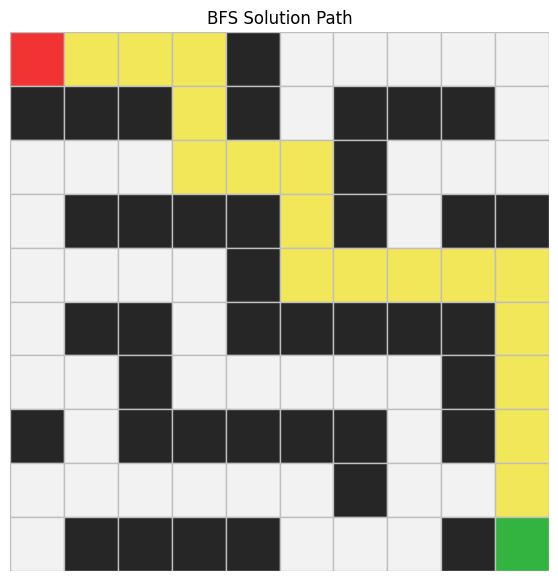

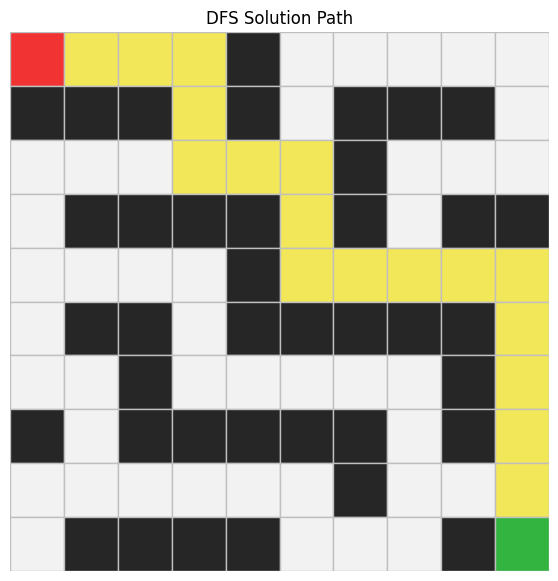

In [34]:
# Visualise solution paths.
# After your algorithms work, choose at least two algorithms and plot their paths.

bfs_result = results[0]
dfs_result = results[1]

plot_path(
    sample_grid,
    start,
    goal,
    path=bfs_result.path,
    title="BFS Solution Path",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=dfs_result.path,
    title="DFS Solution Path",
)

In [35]:
# TODO 10:
# Create your first custom map here.

custom_grid_1 = [
    [1, 1, 0, 1, 1, 1, 1, 1, 1, 1],  # row0 – start at (0,2)
    [1, 1, 0, 0, 1, 1, 1, 0, 1, 1],  # row1 – upward dead ends
    [1, 1, 1, 0, 1, 1, 1, 0, 1, 1],  # row2 – upward dead ends
    [1, 0, 0, 0, 0, 0, 0, 1, 0, 0],  # row3 – main corridor (col1–9)
    [1, 1, 1, 1, 1, 0, 1, 1, 1, 0],  # row4 – downward dead end at col5
    [1, 1, 1, 1, 1, 0, 1, 1, 1, 0],  # row5 – path to goal continues
    [1, 1, 1, 1, 1, 0, 1, 1, 1, 0],  # row6 – path to goal continues
    [1, 1, 1, 1, 1, 0, 1, 1, 1, 0],  # row7 – goal at (7,9)
    [1, 1, 1, 1, 1, 0, 1, 1, 1, 1],  # row8 – deep dead end (col5)
    [1, 1, 1, 1, 1, 0, 1, 1, 1, 1]   # row9 – deep dead end (col5)
]

custom_start_1 = (0, 2)
custom_goal_1 = (7, 9)

# Example after completing:
custom_problem_1 = GridProblem(custom_grid_1, custom_start_1, custom_goal_1)
custom_results_1 = [
     bfs.search(custom_problem_1),
     dfs.search(custom_problem_1),
     dls.search(custom_problem_1, limit=10),
     ids.search(custom_problem_1, max_depth=25),
]
show_results(custom_results_1)

: 

In [ ]:
# TODO 11:
# Create your second custom map here.

custom_grid_2 = [
    # Replace this with your own grid.
    [1, 1, 1, 1, 1, 1, 1],  # row 0
    [1, 0, 0, 0, 1, 1, 1],  # row 1 - upward dead ends (col1-3)
    [1, 0, 0, 0, 1, 1, 1],  # row 2 - upward dead ends (col1-3)
    [0, 0, 0, 0, 0, 0, 0],  # row 3 - main corridor (start at left, goal at right)
    [1, 1, 1, 1, 0, 0, 1],  # row 4 - downward dead ends (col4-5)
    [1, 1, 1, 1, 0, 0, 1],  # row 5 - downward dead ends (col4-5)
    [1, 1, 1, 1, 0, 0, 1]  
]

custom_start_2 = (3,0)
custom_goal_2 = (3,6)

# Example after completing:
custom_problem_2 = GridProblem(custom_grid_2, custom_start_2, custom_goal_2)
custom_results_2 = [
     bfs.search(custom_problem_2),
     dfs.search(custom_problem_2),
     dls.search(custom_problem_2, limit=20),
     ids.search(custom_problem_2, max_depth=40),
]
show_results(custom_results_2)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,Success,NaN,6,6.0,13,36,16
1,DFS,Success,NaN,6,6.0,6,15,12
2,DLS,success,20.0,20,20.0,183,32,0
3,IDS,Success,NaN,6,6.0,148,17,0


# 15.1 Problem Formulation

1. What is a state in this lab?
Answer: A state is basically a location

2. What is an action?
Answer: It is a set of things the state can do

3. What does the result function do?
Answer: Returns the next state after applying an action to the current state

4. Why is it useful to separate the problem definition from   the search algorithm?
Answer: It is useful because it makes it simple to use as well as making it reusable meaning that when seperated you can have the same problem and switch to a different search algorithm without messing it up.


# 15.2 BFS
1. Why does BFS use a FIFO queue?
Answer: This is because its used to explore level by level.

2. Why does BFS find the shortest path in terms of number of steps on the unweighted grid?
Answer: This is because BFS explores every node in order of increasing distance from the start

3. What role does the reached set play in BFS?
Answer: It stores the nodes which have already been expanded


# 15.3 DFS
1. Why does DFS use a stack?
Answer: This because it expands the deepest unexpanded node first

2. Is DFS guaranteed to find the shortest path? Explain.
Answer:No, its not because once it finds the goal it stops so it doesn't matter if the path is short or long

3. Under what conditions can DFS use less memory than BFS?
Answer:When it goes down a path, doesn't find the goal and backtracks to the parent node deleting every expantion it did earlier, thereby freeing up space

4. Under what conditions can DFS perform badly?
Answer:When the path it finds is not the shortest path 


# 15.4 DLS
1. What happens when the depth limit is too small?
Answer: The search algorithm would miss the solution

2. What is the meaning of "cutoff"?
Answer: It is when the state is equal to or greater than the depth limit and so the search stops.

3. How is DLS different from ordinary DFS?
Answer: With DLS the depth limit is specified, meaning the state cannot go beyond that limit but with DFS, there is no limit so it just keeps on going.

4. Why do we use path-cycle checking in DLS?
Answer: DLS has path-cycle checking in order to prevent infinite loops within the current branch being expanded, all while keeping memory usage low.


# 15.5 IDS
1. Why does IDS repeat DLS with increasing limits?
Answer: This is because it is iterative

2. Why can IDS be complete even though DLS with a small limit is not?
Answer: This is because IDS is a combination of both BFS and DLS and so it uses limits but also finds the shortest possible path. 

3. Why does IDS use less memory than BFS?
Answer: This is because IDS backtracks and deletes all the nodes it expanded when it reaches a limit, while BFS still stores all the nodes it expanded even if the goal is not on that path.

4. What is the cost of repeatedly searching from the root?
Answer: It is that shallow nodes gets expanded many times across increasing depth limits but the total time remains while the memory is low


# 15.6 Real-World Drone Context
1. In a real drone application, what might make one route safer or more practical than another?
Answer: It depends on factors such as the drones environment, how far the drone can travel or how much memory it has.

2. Which algorithm would you choose if all moves are equally costly and you only care about the fewest number of moves? Explain.
Answers: Will choose IDS, because it uses less memory and selects the shortest path 

3. Which algorithm would you choose if you want to limit how deep the drone is allowed to search? Explain.
Answers: Will choose DLS, because it sets a depth limit so that the agent doesn't just search one path infinitely

4. What limitations does this grid model have compared with real drone navigation?
Answers: The grid model has been simplified to be 2D where it has perfect movements, static obstacles and has a uniform cost for all free cells however in a real drone navigation there are certain constraints such as velocity and acceleration, wind interference,battery limits and they also have different costs such as no fly areas.